# XGBoost — loan default (full training)

**Training:** `data/raw/Train_Dataset.csv` (uses all rows for the final model).

**Target:** `Default` (1 = default).

**Test file:** `data/raw/Test_Dataset.csv` has the **same feature columns** but **no `Default` column** (typical Kaggle competition layout). You cannot compute accuracy on it from the CSV alone. This notebook:

- Reports **stratified k-fold CV** on the training set (accuracy + ROC-AUC).
- **Fits on the full training set** (no random train/test split).
- **Scores the official test file** and saves predictions.

**Pipeline:** `preprocessing_pipeline.py` — sparse OHE, ANOVA feature selection, XGBoost with `scale_pos_weight` for class imbalance.

**After code changes:** Kernel → Restart & Run All.


## 1. Imports and project root


In [1]:
from pathlib import Path
import importlib
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

sns.set_theme(style="whitegrid")
%matplotlib inline


def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "data" / "raw" / "Train_Dataset.csv").is_file():
            return base
    raise FileNotFoundError("Could not find data/raw/Train_Dataset.csv")


PROJECT_ROOT = find_project_root()
_pp_path = str(PROJECT_ROOT / "models" / "xgboost")
if _pp_path not in sys.path:
    sys.path.insert(0, _pp_path)

import preprocessing_pipeline as pp

importlib.reload(pp)

build_xgb_pipeline = pp.build_xgb_pipeline
feature_importance_series = pp.feature_importance_series
prepare_raw_features = pp.prepare_raw_features
align_features_for_pipeline = pp.align_features_for_pipeline

print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: C:\Users\thaks\Y4S2\ML\ML-ASSIGNMENT


## 2. Paths and hyperparameters


In [2]:
TRAIN_PATH = PROJECT_ROOT / "data" / "raw" / "Train_Dataset.csv"
TEST_PATH = PROJECT_ROOT / "data" / "raw" / "Test_Dataset.csv"
TARGET_COL = "Default"

RANDOM_STATE = 42
CV_FOLDS = 5
SELECT_PERCENTILE = 40.0

OUT_MODEL = PROJECT_ROOT / "outputs" / "xgboost" / "trained_models" / "xgboost_notebook.joblib"
OUT_METRICS = PROJECT_ROOT / "outputs" / "xgboost" / "metrics" / "xgboost_notebook.txt"
OUT_TEST_PREDS = PROJECT_ROOT / "outputs" / "xgboost" / "metrics" / "xgboost_notebook_test_predictions.csv"

print("TRAIN:", TRAIN_PATH)
print("TEST:", TEST_PATH)


TRAIN: C:\Users\thaks\Y4S2\ML\ML-ASSIGNMENT\data\raw\Train_Dataset.csv
TEST: C:\Users\thaks\Y4S2\ML\ML-ASSIGNMENT\data\raw\Test_Dataset.csv


## 3. Load training data (`low_memory=False` for stable dtypes)


In [3]:
df = pd.read_csv(TRAIN_PATH, low_memory=False)
assert TARGET_COL in df.columns, f"Missing {TARGET_COL}"
print("Shape:", df.shape)
df.head()


Shape: (121856, 40)


,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,...,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12142509,6750,0.0,0.0,1.0,0.0,0.0,61190.55,3416.85,Alone,...,Yes,Yes,Self-employed,0.568066,0.478787,NaN,0.0186,63.0,NaN,0
1,12138936,20250,1.0,0.0,1.0,NaN,0.0,15282,1826.55,Alone,...,Yes,Yes,Government,0.563360,0.215068,NaN,NaN,NaN,NaN,0
2,12181264,18000,0.0,0.0,1.0,0.0,1.0,59527.35,2788.2,Alone,...,Yes,Yes,Self-employed,NaN,0.552795,0.329655054,0.0742,277.0,0.0,0
3,12188929,15750,0.0,0.0,1.0,1.0,0.0,53870.4,2295.45,Alone,...,Yes,Yes,XNA,NaN,0.135182,0.631354537,NaN,1700.0,3.0,0
4,12133385,33750,1.0,0.0,1.0,0.0,2.0,133988.4,3547.35,Alone,...,Yes,Yes,Business Entity Type 3,0.508199,0.301182,0.355638717,0.2021,674.0,1.0,0


## 4. Target balance and missing values


In [4]:
print(df[TARGET_COL].value_counts())
print("\nPositive rate:", df[TARGET_COL].mean())
print("\nMissing (top 10):\n", df.isna().sum().sort_values(ascending=False).head(10))


Default
0    112011
1      9845
Name: count, dtype: int64

Positive rate: 0.0807920824579832

Missing (top 10):
 Own_House_Age                 80095
Score_Source_1                68835
Social_Circle_Default         61928
Client_Occupation             41435
Score_Source_3                26921
Credit_Bureau                 18540
ID_Days                        5968
Score_Source_2                 5686
Population_Region_Relative     4857
Loan_Annuity                   4812
dtype: int64


## 5. Prepare features (same as `train.py`)

Numeric columns → `float` (invalid tokens like `\'#\'` → NaN); text-like columns → `str` for OHE.


In [5]:
X = prepare_raw_features(df.drop(columns=[TARGET_COL]))
y = df[TARGET_COL].astype(int)

n_pos = int((y == 1).sum())
n_neg = int((y == 0).sum())
scale_pos_weight = float(n_neg / max(n_pos, 1))
print("scale_pos_weight (neg/pos):", scale_pos_weight)


scale_pos_weight (neg/pos): 11.377450482478416


## 6. Stratified cross-validation (no data held out for final fit)

Uses **all** training rows in rotating folds; mean ± std estimates generalization **without** a fixed random split inside the training file.


In [6]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

base_estimator = build_xgb_pipeline(
    X, select_percentile=SELECT_PERCENTILE, scale_pos_weight=scale_pos_weight
)

print("Cross-validating (this may take several minutes)...")
cv_acc = cross_val_score(
    base_estimator, X, y, cv=cv, scoring="accuracy", n_jobs=1
)
cv_auc = cross_val_score(
    base_estimator, X, y, cv=cv, scoring="roc_auc", n_jobs=1
)

print("CV accuracy: %.4f (+/- %.4f)" % (cv_acc.mean(), cv_acc.std()))
print("CV ROC-AUC:  %.4f (+/- %.4f)" % (cv_auc.mean(), cv_auc.std()))


Cross-validating (this may take several minutes)...
CV accuracy: 0.7067 (+/- 0.0035)
CV ROC-AUC:  0.7224 (+/- 0.0049)


## 7. Fit on **full** training set


In [7]:
model = build_xgb_pipeline(
    X, select_percentile=SELECT_PERCENTILE, scale_pos_weight=scale_pos_weight
)
model.fit(X, y)
print("Fitted on", X.shape[0], "rows.")


Fitted on 121856 rows.


## 8. In-sample metrics (optimistic; use CV above as primary)

Confusion matrix on the training rows — useful for debugging, **not** an unbiased estimate.


Accuracy (in-sample): 0.7237148765756303
ROC-AUC (in-sample): 0.8088096186990703

               precision    recall  f1-score   support

           0       0.97      0.72      0.83    112011
           1       0.19      0.73      0.30      9845

    accuracy                           0.72    121856
   macro avg       0.58      0.73      0.56    121856
weighted avg       0.91      0.72      0.79    121856



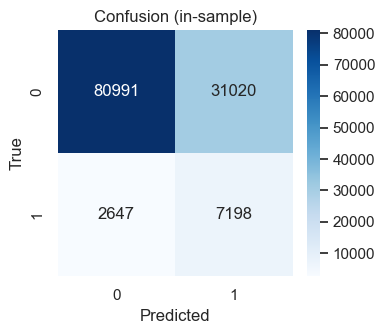

In [8]:
y_hat = model.predict(X)
y_proba = model.predict_proba(X)[:, 1]

print("Accuracy (in-sample):", accuracy_score(y, y_hat))
print("ROC-AUC (in-sample):", roc_auc_score(y, y_proba))
print("\n", classification_report(y, y_hat, zero_division=0))

cm = confusion_matrix(y, y_hat)
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion (in-sample)")
plt.tight_layout()
plt.show()


## 9. Feature importances (top 25)


In [9]:
imp = feature_importance_series(model)
imp.head(25)


cat__Type_Organization_XNA                  0.002715
num__Score_Source_2                         0.002594
cat__Client_Education_Graduation            0.002589
cat__Client_Income_Type_Retired             0.002219
num__Score_Source_1                         0.001603
cat__Credit_Amount_54504                    0.001526
cat__Employed_Days_365243                   0.001495
cat__Type_Organization_Transport: type 2    0.001438
cat__Type_Organization_Security             0.001411
cat__Loan_Annuity_1007.1                    0.001406
cat__Credit_Amount_64008                    0.001380
cat__Score_Source_3_0.832785025             0.001363
cat__Loan_Annuity_2631.6                    0.001355
cat__Client_Gender_Male                     0.001354
cat__Score_Source_3_0.6577838               0.001340
cat__Employed_Days_1551                     0.001339
cat__Client_Education_Secondary             0.001332
cat__Score_Source_3_0.318595524             0.001314
cat__Score_Source_3_0.000527265             0.

## 10. Score `Test_Dataset.csv` (no labels in file)

Saves `ID`, `pred_default`, and `p_default`.


In [10]:
if not TEST_PATH.is_file():
    print("No test file at", TEST_PATH)
else:
    df_test = pd.read_csv(TEST_PATH, low_memory=False)
    if TARGET_COL in df_test.columns:
        df_test = df_test.drop(columns=[TARGET_COL])

    missing = [c for c in X.columns if c not in df_test.columns]
    if missing:
        raise ValueError(f"Test CSV missing columns: {missing}")

    extra = [c for c in df_test.columns if c not in X.columns]
    if extra:
        df_test = df_test.drop(columns=extra)

    X_test = align_features_for_pipeline(model, df_test[X.columns])
    proba = model.predict_proba(X_test)
    p_def = proba[:, 1] if proba.shape[1] > 1 else proba[:, 0]
    sub = pd.DataFrame(
        {
            "ID": X_test["ID"] if "ID" in X_test.columns else np.arange(len(X_test)),
            "pred_default": model.predict(X_test),
            "p_default": p_def,
        }
    )
    OUT_TEST_PREDS.parent.mkdir(parents=True, exist_ok=True)
    sub.to_csv(OUT_TEST_PREDS, index=False)
    print("Saved", OUT_TEST_PREDS, "rows:", len(sub))
    sub.head()


Saved C:\Users\thaks\Y4S2\ML\ML-ASSIGNMENT\outputs\xgboost\metrics\xgboost_notebook_test_predictions.csv rows: 80900


## 11. Save model and metrics


In [11]:
OUT_MODEL.parent.mkdir(parents=True, exist_ok=True)
OUT_METRICS.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(model, OUT_MODEL)

lines = [
    "train_rows=%d" % len(y),
    "scale_pos_weight=%.6f" % scale_pos_weight,
    "cv_folds=%d" % CV_FOLDS,
    "cv_accuracy_mean=%.4f (+/- %.4f)" % (cv_acc.mean(), cv_acc.std()),
    "cv_roc_auc_mean=%.4f (+/- %.4f)" % (cv_auc.mean(), cv_auc.std()),
    "in_sample_accuracy=%.4f" % accuracy_score(y, y_hat),
    "",
    classification_report(y, y_hat, zero_division=0),
]
OUT_METRICS.write_text("\n".join(lines), encoding="utf-8")

print("Saved:", OUT_MODEL)
print("Saved:", OUT_METRICS)


Saved: C:\Users\thaks\Y4S2\ML\ML-ASSIGNMENT\outputs\xgboost\trained_models\xgboost_notebook.joblib
Saved: C:\Users\thaks\Y4S2\ML\ML-ASSIGNMENT\outputs\xgboost\metrics\xgboost_notebook.txt
